In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Dataset path:", path)


Dataset path: C:\Users\dell\.cache\kagglehub\datasets\blastchar\telco-customer-churn\versions\1


In [3]:
import os
print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [4]:
#Data set loading
import pandas as pd
import os
file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(file_path)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info

<bound method DataFrame.info of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL 

In [8]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

In [11]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df = df.drop("customerID", axis=1)

In [13]:
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [15]:
categorical_features = X.select_dtypes(include=["object"]).columns
numerical_features = X.select_dtypes(exclude=["object"]).columns

print("Categorical:", list(categorical_features))
print("Numerical:", list(numerical_features))

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [18]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [19]:
from sklearn.pipeline import Pipeline

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", logistic_model)
])

In [20]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [21]:
y_pred_lr = logistic_pipeline.predict(X_test)

In [22]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42
    ))
])

dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

In [23]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [24]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

In [25]:
y_pred_rf = rf_pipeline.predict(X_test)

In [26]:
from xgboost import XGBClassifier

In [27]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [28]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtect...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [29]:
y_pred_xgb = xgb_pipeline.predict(X_test)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [31]:
def evaluate_model(model, X_test, y_test, y_pred):
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

In [32]:
results = {
    "Logistic Regression": evaluate_model(
        logistic_pipeline, X_test, y_test, y_pred_lr
    ),

    "Decision Tree": evaluate_model(
        dt_pipeline, X_test, y_test, y_pred_dt
    ),

    "Random Forest": evaluate_model(
        rf_pipeline, X_test, y_test, y_pred_rf
    ),

    "XGBoost": evaluate_model(
        xgb_pipeline, X_test, y_test, y_pred_xgb
    )
}

In [33]:
results_df = pd.DataFrame(results).T

results_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.805536,0.657233,0.558824,0.604046,0.841874
Decision Tree,0.728886,0.489637,0.505348,0.497368,0.657266
Random Forest,0.775018,0.597938,0.465241,0.523308,0.818704
XGBoost,0.806955,0.673469,0.529412,0.592814,0.844371


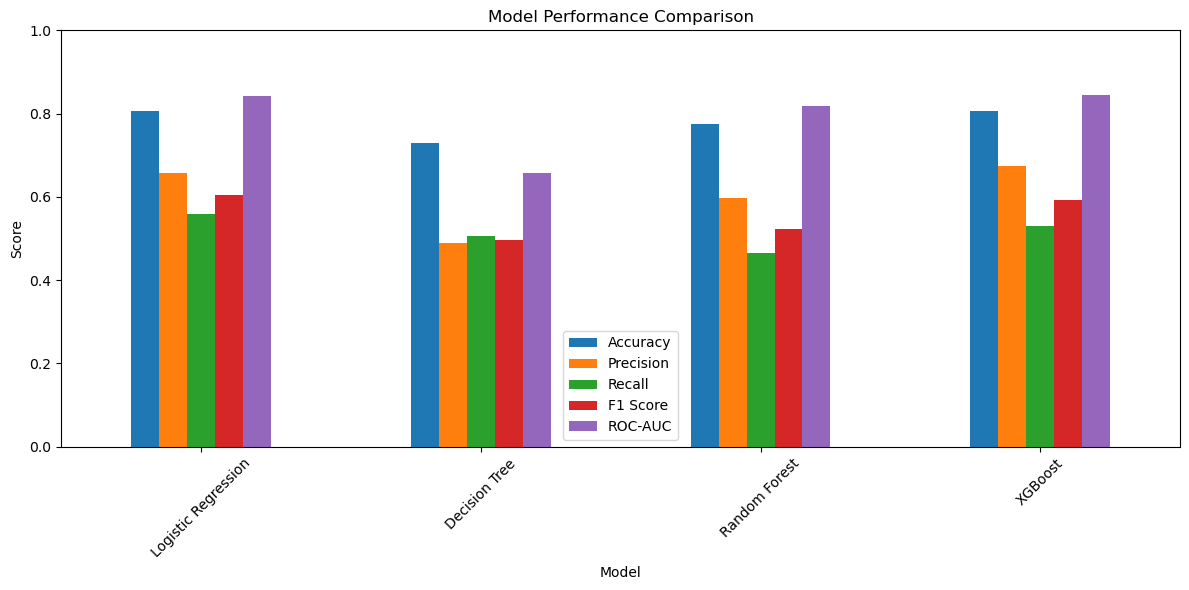

In [34]:
import matplotlib.pyplot as plt

results_df[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [36]:
rf_model = rf_pipeline.named_steps["model"]

In [37]:
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

In [38]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

In [39]:
rf_importance.head(15)

num__TotalCharges                      0.159641
num__tenure                            0.140237
num__MonthlyCharges                    0.138192
cat__Contract_Month-to-month           0.051151
cat__OnlineSecurity_No                 0.033068
cat__PaymentMethod_Electronic check    0.030858
cat__TechSupport_No                    0.028198
cat__InternetService_Fiber optic       0.026041
num__SeniorCitizen                     0.019725
cat__OnlineBackup_No                   0.018340
cat__gender_Female                     0.017730
cat__gender_Male                       0.017691
cat__Contract_Two year                 0.016785
cat__PaperlessBilling_Yes              0.016000
cat__DeviceProtection_No               0.015956
dtype: float64

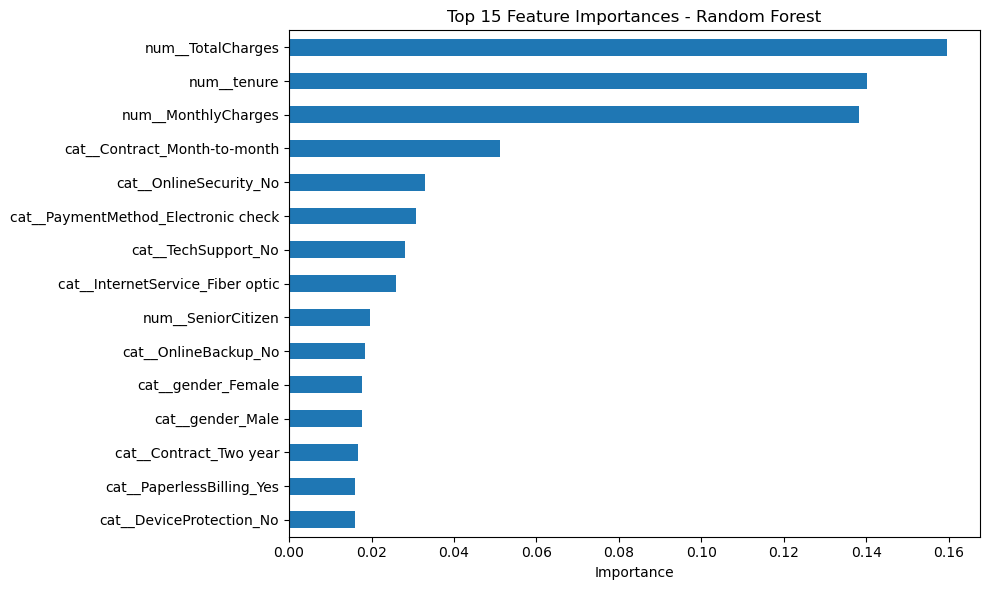

In [40]:
rf_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [41]:
plt.savefig("random_forest_feature_importance.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [42]:
xgb_model = xgb_pipeline.named_steps["model"]

In [43]:
xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

In [44]:
xgb_importance.head(15)

cat__Contract_Month-to-month           0.543593
cat__InternetService_Fiber optic       0.123662
cat__OnlineSecurity_No                 0.036551
cat__TechSupport_No                    0.035456
cat__InternetService_DSL               0.022790
cat__StreamingMovies_Yes               0.018699
cat__Contract_Two year                 0.016951
cat__Contract_One year                 0.016674
num__tenure                            0.016385
cat__OnlineSecurity_Yes                0.015699
cat__PaymentMethod_Electronic check    0.013162
cat__MultipleLines_Yes                 0.012264
cat__PaperlessBilling_No               0.011416
cat__MultipleLines_No                  0.009727
cat__OnlineBackup_Yes                  0.008591
dtype: float32

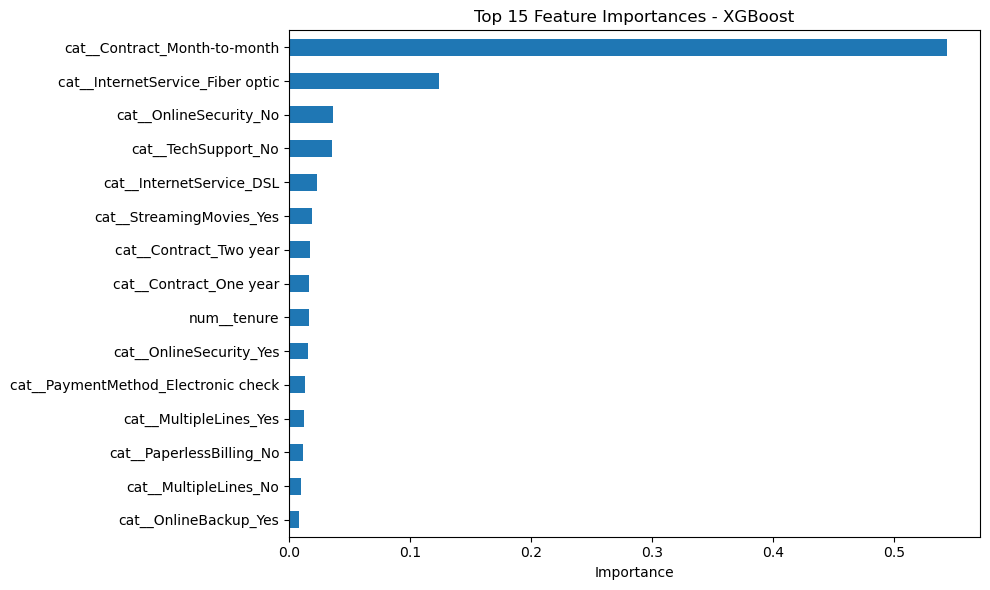

In [45]:
xgb_importance.head(15).sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [46]:
plt.savefig("xgboost_feature_importance.png",
            dpi=300,
            bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [47]:
feature_comparison = pd.DataFrame({
    "Random Forest": rf_importance,
    "XGBoost": xgb_importance
}).fillna(0)

feature_comparison.sort_values(
    "Random Forest",
    ascending=False
).head(15)

,Random Forest,XGBoost
num__TotalCharges,0.159641,0.007285
num__tenure,0.140237,0.016385
num__MonthlyCharges,0.138192,0.008034
cat__Contract_Month-to-month,0.051151,0.543593
cat__OnlineSecurity_No,0.033068,0.036551
cat__PaymentMethod_Electronic check,0.030858,0.013162
cat__TechSupport_No,0.028198,0.035456
cat__InternetService_Fiber optic,0.026041,0.123662
num__SeniorCitizen,0.019725,0.005991
cat__OnlineBackup_No,0.018340,0.007239
